In [1]:
import numpy as np
import matplotlib.pyplot as plt
import process_data as pd

In [2]:
thermal = pd.make_data_dictionary("../results/07-nu_nu_coll.csv", "../results/06-nu_e_coll-eps.csv")

In [3]:
thermal.keys()

dict_keys(['time', 'N_bins', 'rho', 'rhobar', 'f', 'Tcm', 'eps', 'w', 'dnde'])

In [4]:
P0, Px, Py, Pz = pd.make_P(thermal['rho'])

In [5]:
t=thermal['time']

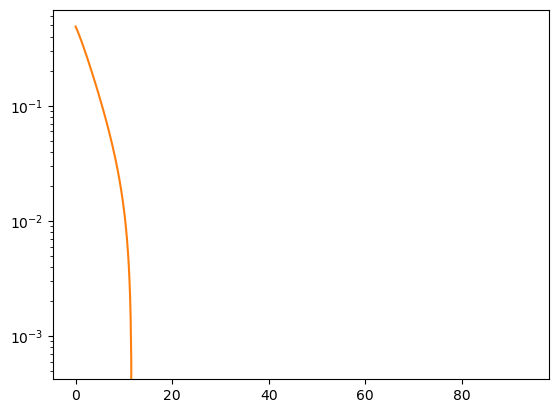

In [6]:
eps=25
plt.semilogy(t[1029:],Pz[1029:,eps])


eps=35
plt.semilogy(t[0:1563],Pz[0:1563,eps])

In [7]:
QKE = pd.make_data_dictionary("../results/62-fix_mat_small.csv", "../results/51-full_QKE-eps.csv")
QKE.keys()

dict_keys(['time', 'N_bins', 'rho', 'rhobar', 'f', 'Tcm', 'eps', 'w', 'dnde'])

In [8]:
P0, Px, Py, Pz = pd.make_P(QKE['rho'])

In [9]:
V_QKE = pd.V_mat(QKE)

In [97]:
t = QKE['time']
f = QKE['f']
Vy = V_QKE[1,:]
dy = np.diff(Vy)

In [11]:
#Finding indices for zero, min, zero, max points (QKE)

tlist = []
Vylist = []

for i in range(len(Vy)-2):
    
    if Vy[i]*Vy[i+1] <= 0:
        tlist.append(i)
        Vylist.append(i)
    if dy[i]*dy[i+1] < 0:
        tlist.append(i)
        Vylist.append(i)

t_index = np.array(tlist)
Vy_index = np.array(Vylist)

(-0.03, 0.03)

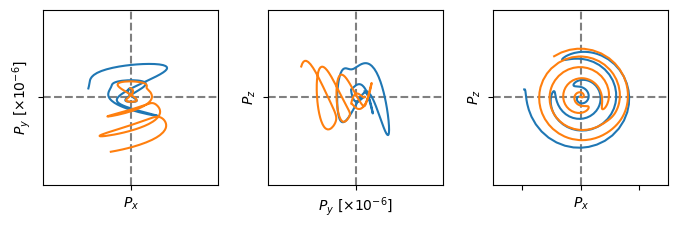

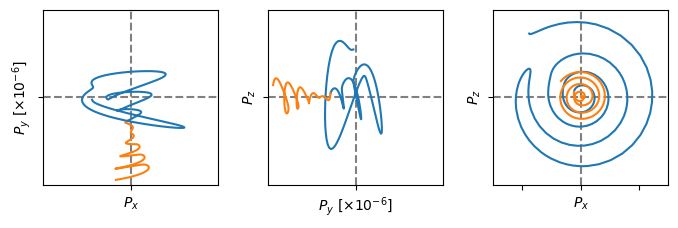

In [95]:
eps=25

fig = plt.figure(figsize=(7,2.5))

array = ([0, 27, 48, 70, 90, 111])
xy = fig.add_axes([2/28, 1/10, 7/28, 7/10])
yz = fig.add_axes([11/28, 1/10, 7/28, 7/10])
xz = fig.add_axes([20/28, 1/10, 7/28, 7/10])

bloch = [xy, yz, xz]

for ax in bloch:
    ax.axhline(0, c='0.50', ls='--')
    ax.axvline(0, c='0.50', ls='--')

label_fontsize = 10

#xy1.scatter(Px[t_index,15][1:9], Py[t_index,15][1:9]*1e6)
#xy.scatter(Px[t_index,15][0],Py[t_index,15][0]*1e6, marker='^', color='green', s=50, label=r"$t_0$")
#xy.scatter(Px[t_index,15][8],Py[t_index,15][8]*1e6, marker='s', color='red', s=50, label=r"$t_f$")
xy.plot(Px[t_index[38] : t_index[46],eps], Py[t_index[38] : t_index[46],eps]*1e6)
xy.plot(Px[t_index[46] : t_index[55],eps], Py[t_index[46] : t_index[55],eps]*1e6)
xy.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xy.set_ylabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
xy.set_xticks([-0.2, 0, 0.2])
xy.set_yticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
xy.tick_params(labelbottom=False, labelleft=False)
xy.set_xlim(-0.04,0.04)
xy.set_ylim(-0.07,0.07)
#xy.add_patch(plt.Rectangle((-.2, -.35), .4, .7, ls="--", fc="none", ec="c"))

#yz1.scatter(Py[t_index,15][1:9]*1e6, Pz[t_index,15][1:9])
#yz.scatter(Py[t_index,15][0]*1e6,Pz[t_index,15][0], marker='^', color='green', s=50, label=r"$t_0$")
#z.scatter(Py[t_index,15][8]*1e6,Pz[t_index,15][8], marker='s', color='red', s=50, label=r"$t_f$")
yz.plot(Py[t_index[38] : t_index[46],eps]*1e6, Pz[t_index[38] : t_index[46],eps])
yz.plot(Py[t_index[46] : t_index[55],eps]*1e6, Pz[t_index[46] : t_index[55],eps])
yz.set_xlabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
yz.set_ylabel(r"$P_z$", fontsize=label_fontsize)
yz.set_yticks([-0.2, 0, 0.2])
yz.set_xticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
yz.tick_params(labelbottom=False, labelleft=False) 
yz.set_xlim(-0.07,0.07)
yz.set_ylim(-0.04,0.04)

#xz1.scatter(Pz[t_index,15][1:9],Px[t_index,15][1:9])
#xz.scatter(Px[t_index,15][0],Pz[t_index,15][0], marker='^', color='green', s=50, label=r"$t_0$")
#xz.scatter(Px[t_index,15][8],Pz[t_index,15][8], marker='s', color='red', s=50, label=r"$t_f$")
xz.plot(Px[t_index[38] : t_index[46],eps], Pz[t_index[38] : t_index[46],eps])
xz.plot(Px[t_index[46] : t_index[55],eps], Pz[t_index[46] : t_index[55],eps])
xz.set_ylabel(r"$P_z$", fontsize=label_fontsize)
xz.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xz.set_yticks([-0.2, 0, 0.2])
xz.set_yticks([-0.2, 0, 0.2])
xz.tick_params(labelbottom=False, labelleft=False) 
xz.set_xlim(-0.03,0.03)
xz.set_ylim(-0.03,0.03)
#xz.add_patch(plt.Rectangle((-.2, -.2), .4, .4, ls="--", fc="none", ec="c"))





eps=35

fig = plt.figure(figsize=(7,2.5))

array = ([0, 27, 48, 70, 90, 111])
xy = fig.add_axes([2/28, 1/10, 7/28, 7/10])
yz = fig.add_axes([11/28, 1/10, 7/28, 7/10])
xz = fig.add_axes([20/28, 1/10, 7/28, 7/10])

bloch = [xy, yz, xz]

for ax in bloch:
    ax.axhline(0, c='0.50', ls='--')
    ax.axvline(0, c='0.50', ls='--')

label_fontsize = 10

#xy1.scatter(Px[t_index,15][1:9], Py[t_index,15][1:9]*1e6)
#xy.scatter(Px[t_index,15][0],Py[t_index,15][0]*1e6, marker='^', color='green', s=50, label=r"$t_0$")
#xy.scatter(Px[t_index,15][8],Py[t_index,15][8]*1e6, marker='s', color='red', s=50, label=r"$t_f$")
xy.plot(Px[t_index[48] : t_index[56],eps], Py[t_index[48] : t_index[56],eps]*1e6)
xy.plot(Px[t_index[56] : t_index[65],eps], Py[t_index[56] : t_index[65],eps]*1e6)
xy.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xy.set_ylabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
xy.set_xticks([-0.2, 0, 0.2])
xy.set_yticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
xy.tick_params(labelbottom=False, labelleft=False)
xy.set_xlim(-0.04,0.04)
xy.set_ylim(-.07,.07)
#xy.add_patch(plt.Rectangle((-.2, -.35), .4, .7, ls="--", fc="none", ec="c"))

#yz1.scatter(Py[t_index,15][1:9]*1e6, Pz[t_index,15][1:9])
#yz.scatter(Py[t_index,15][0]*1e6,Pz[t_index,15][0], marker='^', color='green', s=50, label=r"$t_0$")
#z.scatter(Py[t_index,15][8]*1e6,Pz[t_index,15][8], marker='s', color='red', s=50, label=r"$t_f$")
yz.plot(Py[t_index[48] : t_index[56],eps]*1e6, Pz[t_index[48] : t_index[56],eps])
yz.plot(Py[t_index[56] : t_index[65],eps]*1e6, Pz[t_index[56] : t_index[65],eps])
yz.set_xlabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
yz.set_ylabel(r"$P_z$", fontsize=label_fontsize)
yz.set_yticks([-0.2, 0, 0.2])
yz.set_xticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
yz.tick_params(labelbottom=False, labelleft=False) 
yz.set_xlim(-.07,.07)
yz.set_ylim(-0.04,0.04)

#xz1.scatter(Pz[t_index,15][1:9],Px[t_index,15][1:9])
#xz.scatter(Px[t_index,15][0],Pz[t_index,15][0], marker='^', color='green', s=50, label=r"$t_0$")
#xz.scatter(Px[t_index,15][8],Pz[t_index,15][8], marker='s', color='red', s=50, label=r"$t_f$")
xz.plot(Px[t_index[48] : t_index[56],eps], Pz[t_index[48] : t_index[56],eps])
xz.plot(Px[t_index[56] : t_index[65],eps], Pz[t_index[56] : t_index[65],eps])
xz.set_ylabel(r"$P_z$", fontsize=label_fontsize)
xz.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xz.set_yticks([-0.2, 0, 0.2])
xz.set_yticks([-0.2, 0, 0.2])
xz.tick_params(labelbottom=False, labelleft=False) 
xz.set_xlim(-0.03,0.03)
xz.set_ylim(-0.03,0.03)
#xz.add_patch(plt.Rectangle((-.2, -.2), .4, .4, ls="--", fc="none", ec="c"))


In [13]:
np.where(QKE['time']<11)[0][-1]

1563

In [14]:
np.where(QKE['time']<8)[0][-1]

1029

In [15]:
print(t_index)

[   0   19   38   53   74   92  113  130  151  170  193  213  236  285
  307  332  354  431  448  465  484  501  520  537  556  574  593  611
  631  648  670  688  709  728  752  770  795  814  842  861  890  910
  938  960  989 1011 1040 1066 1096 1124 1172 1266 1313 1363 1460 1545
 1656 1763 1882 1999 2156 2286 2540 2704 3017 3227 3560 3810 4145 4425
 4764 5067]


In [71]:
print(t_index[55])

1545


In [113]:
f_array=np.array(f)
print(t.shape)
print(f_array.shape)

(5300,)
(4, 5300, 206)


(0.0, 6.0)

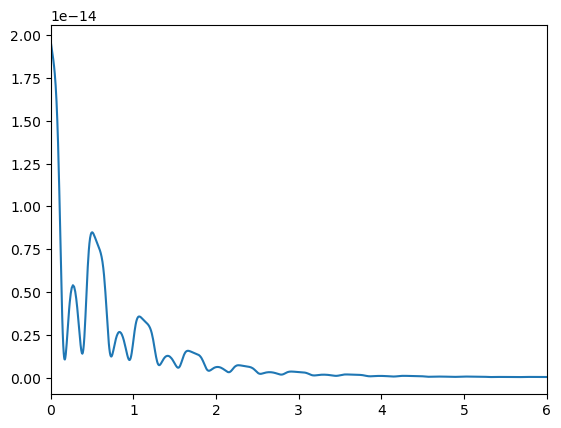

In [127]:
plt.plot(t, f[pd.NU_E][:, -1])
plt.xlim(0,6)